In [3]:
pip install pandas numpy matplotlib scikit-learn seaborn

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load Dataset
dataset = pd.read_csv("Social_Network_Ads.csv")

# Select Features
X = dataset[['Age','EstimatedSalary']]
y = dataset['Purchased']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=0)

# Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Dictionary to store results
results = {}

# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train,y_train)
pred_log = log_model.predict(X_test)
results["Logistic Regression"] = accuracy_score(y_test,pred_log)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
pred_knn = knn.predict(X_test)
results["KNN"] = accuracy_score(y_test,pred_knn)

# SVM
svm = SVC(kernel='rbf')
svm.fit(X_train,y_train)
pred_svm = svm.predict(X_test)
results["SVM"] = accuracy_score(y_test,pred_svm)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
pred_dt = dt.predict(X_test)
results["Decision Tree"] = accuracy_score(y_test,pred_dt)

# Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)
results["Random Forest"] = accuracy_score(y_test,pred_rf)

# Print Results
print("Accuracy of Models:\n")

for model,acc in results.items():
    print(model,"=",round(acc*100,2),"%")

Accuracy of Models:

Logistic Regression = 89.0 %
KNN = 93.0 %
SVM = 93.0 %
Decision Tree = 90.0 %
Random Forest = 91.0 %


### Code to Predict New Customers

In [10]:
test_data = [
    [30,87000],
    [40,0],
    [40,100000],
    [50,0],
    [18,0],
    [22,600000],
    [35,2500000],
    [60,100000000]
]

test_data = sc.transform(test_data)

predictions = rf.predict(test_data)

for i,p in enumerate(predictions):
    if p == 1:
        print("Customer",i+1,"-> Will Purchase Insurance")
    else:
        print("Customer",i+1,"-> Will NOT Purchase Insurance")

Customer 1 -> Will NOT Purchase Insurance
Customer 2 -> Will NOT Purchase Insurance
Customer 3 -> Will Purchase Insurance
Customer 4 -> Will Purchase Insurance
Customer 5 -> Will NOT Purchase Insurance
Customer 6 -> Will Purchase Insurance
Customer 7 -> Will Purchase Insurance
Customer 8 -> Will Purchase Insurance


C:\Users\sande\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Graphical Analysis Code

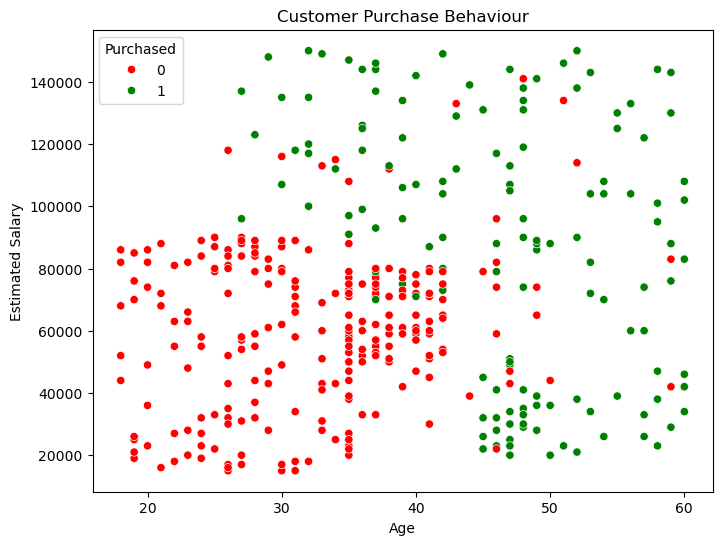

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=dataset['Age'],
    y=dataset['EstimatedSalary'],
    hue=dataset['Purchased'],
    palette=['red','green']
)

plt.title("Customer Purchase Behaviour")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()